In [ ]:
!pip install pystac-client planetary-computer stackstac dask[complete] \
            geopandas shapely pyproj rasterio numpy xarray pandas matplotlib


EPSG: 32612 | Zakres czasu: 2024-01-01/2024-12-31
✅ Zapisano: out/swir1_points_timeseries_2024-01-01_2024-12-31_max.csv


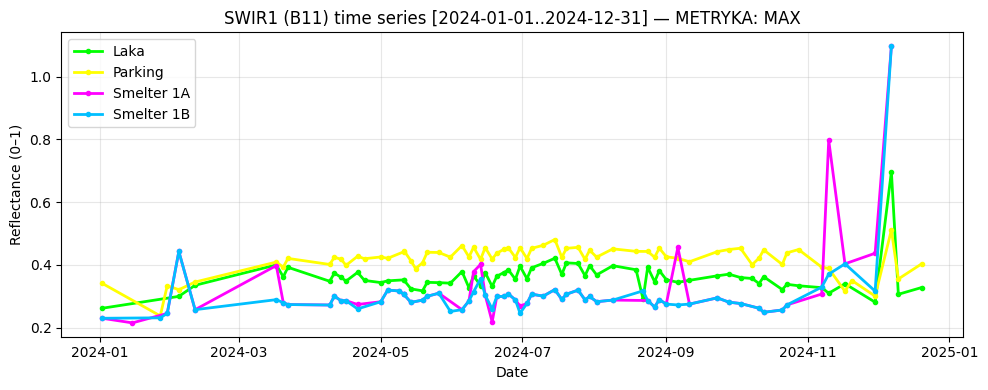

In [35]:
# === Sentinel-2 L2A SWIR1 (B11) time-series for multiple points (MPC, no GEE) ===
# pip install pystac-client planetary-computer stackstac geopandas shapely rasterio xarray numpy pandas matplotlib python-dateutil

import os, time, warnings
import numpy as np, pandas as pd, xarray as xr
import geopandas as gpd
from shapely.geometry import Point
from pystac_client import Client
import planetary_computer as pc
import stackstac, rasterio
from rasterio.features import rasterize
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.makedirs("out", exist_ok=True)

# ---------------------------
# 1) PARAMS (edit here)
# ---------------------------
DATE_START = "2024-01-01"
DATE_END   = "2024-12-31"
CLOUD_COVER_LT = 60           # luźniej, bo i tak maskujemy SCL
POINT_BUFFER_M = 30           # bufor jak reduceRegion w GEE
METRIC = "max"                # "max" (Twoje wymaganie) lub "mean"
TOPLOT_COLORS = {
    "Laka":       "#00FF00",
    "Parking":    "#FFFF00",
    "Smelter 1A": "#FF00FF",
    "Smelter 1B": "#00BFFF",
}

# punkty (lon, lat) jak w Twoim GEE
points = {
  "Laka":        (-112.213216, 40.720848),
  "Parking":     (-112.215923, 40.722166),
  "Smelter 1A":  (-112.20487,  40.721762),
  "Smelter 1B":  (-112.2051097,40.721769),
}

# ——— GDAL env, które stabilizuje dostęp do blobów (Windows/VSICURL) ———
GDAL_ENV = dict(
    CPL_VSIL_CURL_USE_HEAD=False,               # nie używaj HEAD (częste 403/redirect)
    GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",   # nie listuj katalogów w chmurze
    CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif,.TIF"
)

# ---------------------------
# 2) AOI & EPSG (UTM)
# ---------------------------
def lonlat_to_utm_epsg(lon, lat):
    zone = int(np.floor((lon + 180)/6) + 1)
    return 32600 + zone if lat >= 0 else 32700 + zone

lon_c = np.mean([p[0] for p in points.values()])
lat_c = np.mean([p[1] for p in points.values()])
EPSG = lonlat_to_utm_epsg(lon_c, lat_c)
print("EPSG:", EPSG, "| Zakres czasu:", f"{DATE_START}/{DATE_END}")

gdf_pts = gpd.GeoDataFrame(
    {"label": list(points.keys())},
    geometry=[Point(lon, lat) for lon,lat in points.values()],
    crs=4326,
)
gdf_buf_merc = gdf_pts.to_crs(3857)
gdf_buf_merc["geometry"] = gdf_buf_merc.buffer(POINT_BUFFER_M)
gdf_buf_wgs  = gdf_buf_merc.to_crs(4326)
gdf_buf_utm  = gdf_buf_merc.to_crs(EPSG)

# AOI bbox (UTM) z niewielkim marginesem
minx, miny, maxx, maxy = gdf_buf_utm.total_bounds
bounds_utm = (minx - 100, miny - 100, maxx + 100, maxy + 100)

# ---------------------------
# 3) STAC search (MPC) & stack
# ---------------------------
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=gdf_buf_wgs.unary_union.__geo_interface__,
    datetime=f"{DATE_START}/{DATE_END}",
    query={"eo:cloud_cover": {"lt": CLOUD_COVER_LT}},
)
items_raw = list(search.get_items())
if not items_raw:
    raise SystemExit("Brak scen w zadanym zakresie.")

def build_stack_fresh(items):
    signed = [pc.sign(it) for it in items]  # świeże SAS
    with rasterio.Env(**GDAL_ENV):          # <<< kluczowe dla stabilności I/O
        stk = stackstac.stack(
            signed,
            assets=["B11","SCL"],           # TYLKO SWIR1 + maska (żeby ominąć B12)
            bounds=bounds_utm,
            resolution=20,                  # natywne dla B11
            dtype="float64",
            rescale=False,
            epsg=EPSG
        )
    # szybki "touch", by od razu wyłapać ewentualne 403/I/O
    _ = stk.sel(band="B11").isel(time=0, drop=True).values
    return stk

# retry przy 403/VSICURL
for attempt in (1, 2, 3):
    try:
        stk = build_stack_fresh(items_raw)
        break
    except Exception as e:
        msg = str(e)
        if attempt < 3 and (
            "HTTP response code: 403" in msg
            or "OpenFailed" in msg
            or "not recognized as a supported file format" in msg
        ):
            print(f"⚠️ problem z dostępem (próba {attempt}) — odświeżam podpis i próbuję ponownie...")
            time.sleep(1.0)
            continue
        raise

# ---------------------------
# 4) Cloud mask (SCL) + per-point masks
# ---------------------------
SCL = stk.sel(band="SCL").astype("uint16")             # (time,y,x)
bad = SCL.isin([0,1,3,8,9,10,11])                      # chmury/cienie/śnieg
good = ~bad

# rasteryzuj maski buforów w siatce stacka
ref = stk.sel(band="B11").isel(time=0, drop=True)
transform = rasterio.Affine(ref.x[1]-ref.x[0], 0, ref.x[0],
                            0, ref.y[1]-ref.y[0], ref.y[0])
H, W = ref.sizes["y"], ref.sizes["x"]

def rasterize_shape(geom_utm):
    return rasterize(
        [geom_utm.__geo_interface__],
        out_shape=(H, W),
        transform=transform,
        fill=0, default_value=1, dtype="uint8"
    ).astype(bool)

point_masks_2d = {row.label: xr.DataArray(
    rasterize_shape(row.geometry), dims=("y","x"),
    coords={"y": stk.y, "x": stk.x}
) for _, row in gdf_buf_utm.iterrows()}

point_masks_3d = {k: v.broadcast_like(SCL) for k, v in point_masks_2d.items()}

# SWIR1 reflectance (0–1) + maska chmur
B11 = (stk.sel(band="B11") / 10000.0).where(good)

# ---------------------------
# 5) ReduceRegion-equiv: METRYKA dla każdego punktu i daty
# ---------------------------
rows = []
for label, m3d in point_masks_3d.items():
    b11_pt = B11.where(m3d)  # maskuj do bufora punktu

    if METRIC == "mean":
        ts = b11_pt.mean(dim=("y","x")).compute().to_series().rename("SWIR1")
    elif METRIC == "max":
        ts = b11_pt.max(dim=("y","x")).compute().to_series().rename("SWIR1")
    else:
        raise ValueError("METRIC must be 'mean' or 'max'")

    ts = ts.dropna().sort_index()
    if ts.empty:
        continue
    df = ts.reset_index()
    df.columns = ["date", "SWIR1"]
    df["label"] = label
    rows.append(df)

if not rows:
    raise SystemExit("Brak próbek po maskach (spróbuj większego bufora lub zwiększ CLOUD_COVER_LT).")

result = pd.concat(rows, ignore_index=True)
result["date"] = pd.to_datetime(result["date"]).dt.date

# zapis CSV
out_csv = f"out/swir1_points_timeseries_{DATE_START}_{DATE_END}_{METRIC}.csv"
result.to_csv(out_csv, index=False, float_format="%.4f")
print("✅ Zapisano:", out_csv)

# ---------------------------
# 6) Wykres grupowany (jak w GEE), SWIR1 tylko
# ---------------------------
plt.figure(figsize=(10,4))
for label, g in result.groupby("label"):
    g = g.sort_values("date")
    plt.plot(
        g["date"], g["SWIR1"], marker="o", linewidth=2, markersize=3,
        label=label, color=TOPLOT_COLORS.get(label, None)
    )
plt.title(f"SWIR1 (B11) time series [{DATE_START}..{DATE_END}] — METRYKA: {METRIC.upper()}")
plt.xlabel("Date"); plt.ylabel("Reflectance (0–1)")
plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()
